In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
def wrangle(file):
    df = pd.read_csv(file).set_index("customerID")

    #convert cat featurs to numeric
    mapping = {"No":0, "Yes":1}
    df["Partner"] = df["Partner"].map(mapping)
    df["Dependents"] = df["Dependents"].map(mapping)
    df["PhoneService"] = df["PhoneService"].map(mapping)
    df["PaperlessBilling"] = df["PaperlessBilling"].map(mapping)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    return df
    

In [19]:
df = wrangle("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,Yes


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null 

## Exploring numaric features

In [21]:
numaric_data = df.select_dtypes(include="number")
numaric_data.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges
customerID,,,,,,,,
7590-VHVEG,0,1,0,1,0,1,29.85,29.85
5575-GNVDE,0,0,0,34,1,0,56.95,1889.50
3668-QPYBK,0,0,0,2,1,1,53.85,108.15
7795-CFOCW,0,0,0,45,0,0,42.30,1840.75
9237-HQITU,0,0,0,2,1,1,70.70,151.65


In [22]:
numaric_data.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000


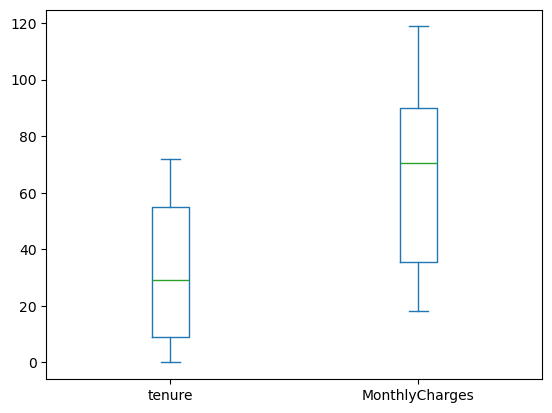

In [23]:
numaric_data[["tenure","MonthlyCharges"]].plot(kind="box");

<Axes: xlabel='SeniorCitizen'>

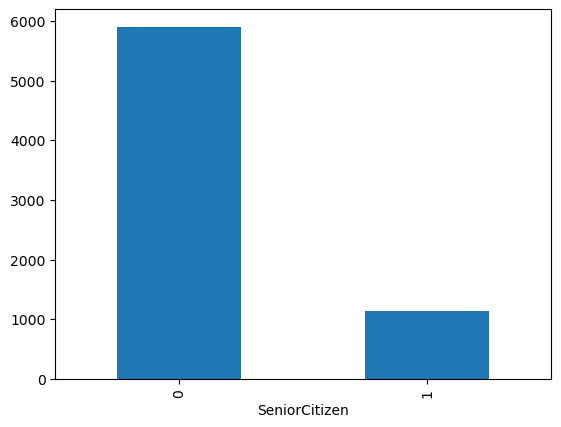

In [24]:
numaric_data.SeniorCitizen.value_counts().plot(kind="bar")

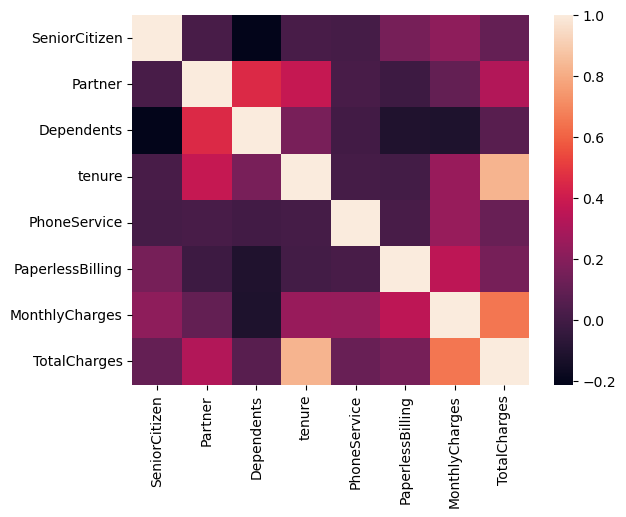

In [25]:
corr = numaric_data.corr()
sns.heatmap(corr);

## Exploring categorical features

In [26]:
cat_data = df.select_dtypes(exclude="number")
cat_data.head()

,gender,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
customerID,,,,,,,,,,,,
7590-VHVEG,Female,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check,No
5575-GNVDE,Male,No,DSL,Yes,No,Yes,No,No,No,One year,Mailed check,No
3668-QPYBK,Male,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,Yes
7795-CFOCW,Male,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic),No
9237-HQITU,Female,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check,Yes


In [31]:
cat_data.nunique()

gender              2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaymentMethod       4
Churn               2
dtype: int64

<Axes: xlabel='MultipleLines'>

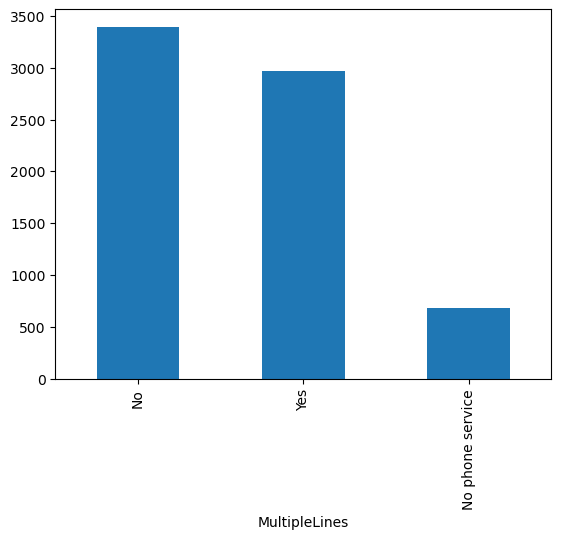

In [32]:
cat_data["MultipleLines"].value_counts().plot(kind="bar")   

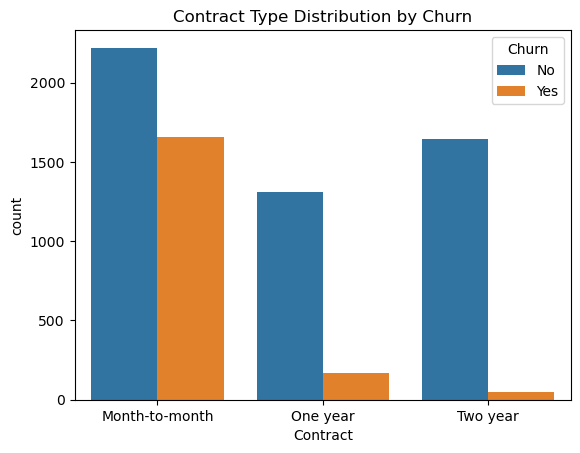

In [28]:
# distribution of TotalCharges by Churn
sns.countplot(x=cat_data["Contract"], hue=cat_data["Churn"])
plt.title("Contract Type Distribution by Churn")
plt.show();

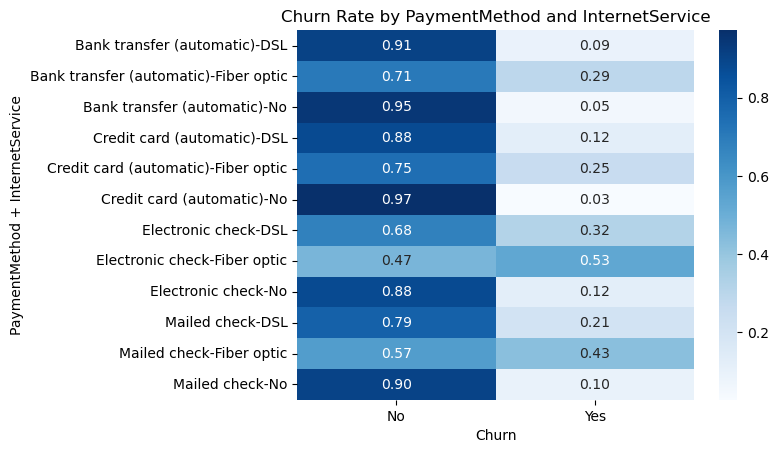

In [29]:
# Crosstab of PaymentMethod  vs InternetService with Churn counts
ct = pd.crosstab([cat_data['PaymentMethod'], cat_data['InternetService']], cat_data['Churn'])

# Normalize to percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0)

# Heatmap
sns.heatmap(ct_pct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Churn Rate by PaymentMethod and InternetService")
plt.ylabel("PaymentMethod + InternetService")
plt.xlabel("Churn")
plt.show()


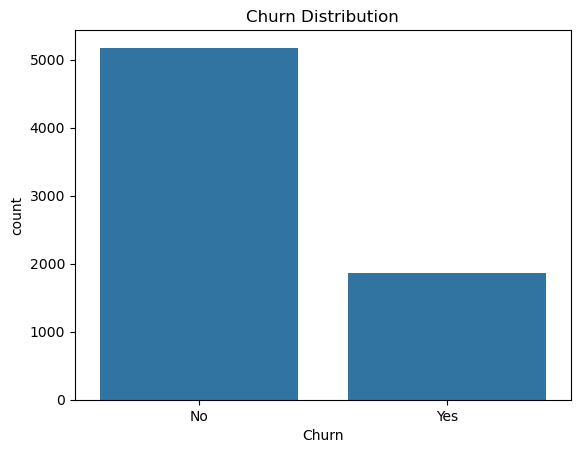

In [34]:
# finalyy let's look at the target variable distribution
sns.countplot(x=cat_data["Churn"])
plt.title("Churn Distribution");